# Network Analysis: Friendship Paradox and Clustering
## 1. Network Generation
We generate three types of networks:
1. Erdős-Rényi (ER) random network
2. Barabási-Albert (BA) scale-free network
3. Watts-Strogatz (WS) small-world network

In [6]:
pip install numpy networkx matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 15.0 MB/s  0:00:01 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Network parameters
n = 1000
k_avg = 4

# (a) Erdős-Rényi random network
p_er = k_avg / (n - 1)
G_er = nx.erdos_renyi_graph(n=n, p=p_er, seed=42)

# (b) Barabási-Albert scale-free network
m = int(k_avg / 2)  # Average degree is 2m, so m = 2
G_ba = nx.barabasi_albert_graph(n=n, m=m, seed=42)

# (c) Watts-Strogatz small-world network
k_ws = 4
p_ws = 0.1
G_ws = nx.watts_strogatz_graph(n=n, k=k_ws, p=p_ws, seed=42)

networks = {'ER': G_er, 'BA': G_ba, 'WS': G_ws}
print("Networks generated successfully.")

Matplotlib is building the font cache; this may take a moment.


Networks generated successfully.


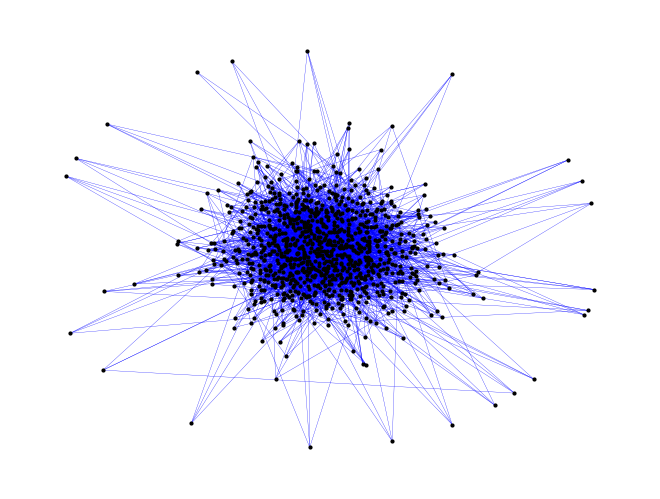

In [23]:
# Compute node positions using the spring layout algorithm
pos = nx.spring_layout(G_er) 

# Draw the graph with the specified positions
# nx.draw(G, pos, with_labels=False, node_color='black', edge_color='blue', node_size=4, width=0.1)
nx.draw(G, pos, with_labels=False, node_color='black', edge_color='blue', node_size=4, width=0.2)

# Display the plot
plt.show()

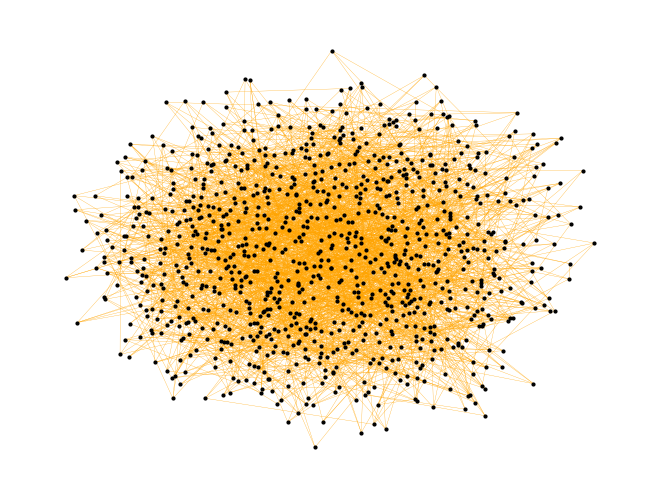

In [30]:
# Compute node positions using the spring layout algorithm
pos = nx.spring_layout(G_ba) 

# Draw the graph with the specified positions
# nx.draw(G, pos, with_labels=False, node_color='black', edge_color='blue', node_size=4, width=0.1)
nx.draw(G, pos, with_labels=False, node_color='black', edge_color='orange', node_size=4, width=0.2)

# Display the plot
plt.show()

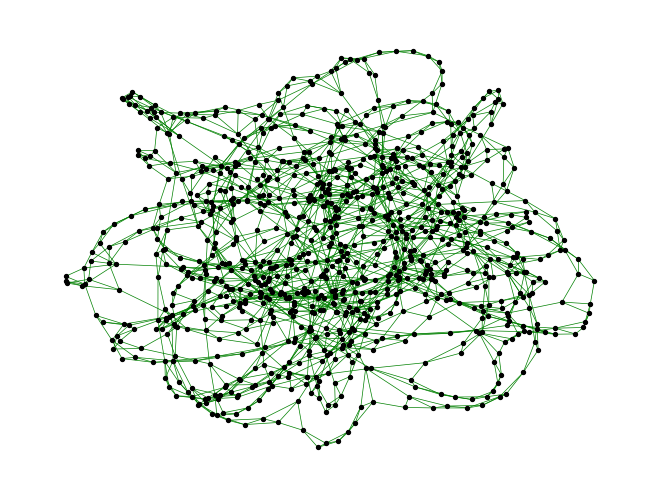

In [38]:
# Compute node positions using the spring layout algorithm
pos = nx.spring_layout(G_ws) 

# Draw the graph with the specified positions
# nx.draw(G, pos, with_labels=False, node_color='black', edge_color='blue', node_size=4, width=0.1)
nx.draw(G, pos, with_labels=False, node_color='black', edge_color='green', node_size=8, width=0.5)

# Display the plot
plt.show()

## 2. Empirical Verification of the Friendship Paradox
The Friendship Paradox formally states that in a network, the average degree of a node's neighbors is greater than the average degree of a node in the network.
We will verify this by comparing the local average node degree with the local average neighbor degree.

--- ER Network ---
Average Node Degree: 3.9760
Average Neighbor Degree: 4.9049
Friendship paradox holds: True

--- BA Network ---
Average Node Degree: 3.9920
Average Neighbor Degree: 12.4387
Friendship paradox holds: True

--- WS Network ---
Average Node Degree: 4.0000
Average Neighbor Degree: 4.0891
Friendship paradox holds: True



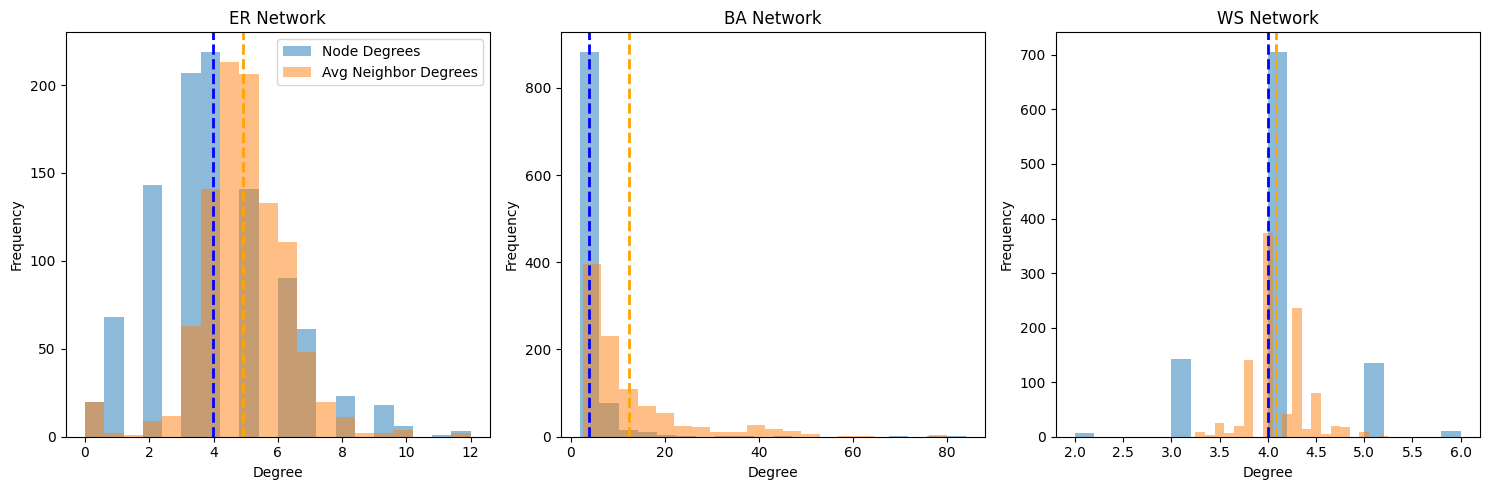

In [2]:
def check_friendship_paradox(G, name):
    degrees = dict(G.degree())
    node_degrees = list(degrees.values())
    avg_node_degree = np.mean(node_degrees)
    
    neighbor_degrees = []
    for u in G.nodes():
        neighbors = list(G.neighbors(u))
        if len(neighbors) > 0:
            avg_neighbor_deg = np.mean([degrees[v] for v in neighbors])
            neighbor_degrees.append(avg_neighbor_deg)
        else:
            neighbor_degrees.append(0)
            
    avg_neighbor_degree = np.mean(neighbor_degrees)
    
    print(f"--- {name} Network ---")
    print(f"Average Node Degree: {avg_node_degree:.4f}")
    print(f"Average Neighbor Degree: {avg_neighbor_degree:.4f}")
    print(f"Friendship paradox holds: {avg_neighbor_degree > avg_node_degree}\n")
    
    return node_degrees, neighbor_degrees

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (name, G) in enumerate(networks.items()):
    node_degrees, neighbor_degrees = check_friendship_paradox(G, name)
    
    ax = axes[i]
    ax.hist(node_degrees, bins=20, alpha=0.5, label="Node Degrees")
    ax.hist(neighbor_degrees, bins=20, alpha=0.5, label="Avg Neighbor Degrees")
    ax.axvline(np.mean(node_degrees), color='blue', linestyle='dashed', linewidth=2)
    ax.axvline(np.mean(neighbor_degrees), color='orange', linestyle='dashed', linewidth=2)
    ax.set_title(f"{name} Network")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Frequency")
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

## 3. Clustering Coefficient
We measure the clustering coefficient and compare it with the theoretical prediction.

In [3]:
def theoretical_clustering(name, n):
    if name == 'ER':
        # C = p = <k> / (n - 1)
        return k_avg / (n - 1)
    elif name == 'BA':
        # For BA with m=2, standard large N asymptotic goes to 0 as ~ (ln(N)^2) / N.
        return "Approaches 0 for large N."
    elif name == 'WS':
        # C0 = 3(k-2)/(4(k-1))
        # C = C0 * (1-p)^3
        k_ws = 4
        p_ws = 0.1
        C0 = 3 * (k_ws - 2) / (4 * (k_ws - 1))
        return C0 * ((1 - p_ws) ** 3)

for name, G in networks.items():
    c_emp = nx.average_clustering(G)
    c_theo = theoretical_clustering(name, n)
    
    print(f"--- {name} Network ---")
    print(f"Empirical Clustering Coefficient: {c_emp:.4f}")
    if isinstance(c_theo, float):
        print(f"Theoretical Clustering Coefficient: {c_theo:.4f}")
    else:
        print(f"Theoretical Clustering Coefficient: {c_theo}")
    print()

--- ER Network ---
Empirical Clustering Coefficient: 0.0059
Theoretical Clustering Coefficient: 0.0040

--- BA Network ---
Empirical Clustering Coefficient: 0.0307
Theoretical Clustering Coefficient: Approaches 0 for large N.

--- WS Network ---
Empirical Clustering Coefficient: 0.3879
Theoretical Clustering Coefficient: 0.3645



## 4. Discussion and Report

### Friendship Paradox
For all three networks, the empirical findings strongly support the **Friendship Paradox**: the average degree of a node's neighbors is consistently higher than the average node degree. This happens because high-degree nodes (hubs) naturally appear in more neighborhood lists, disproportionately pulling up the neighbor degree averages. The effect is particularly pronounced in the **BA (scale-free) network**, where the presence of massive hubs (due to preferential attachment) makes the average neighbor degree significantly larger compared to the others. 

### Clustering Coefficient Discrepancies
1. **Erdős-Rényi (ER)**: The empirical clustering coefficient aligns closely with the theoretical prediction ($C \approx p = 4/999 \approx 0.004$). Minor differences are strictly due to random fluctuations in the network's specific realization.
2. **Barabási-Albert (BA)**: The empirical clustering coefficient is quite small, matching the analytical expectation that BA networks lack inherent short-range clustering mechanisms. Because it decays with network size $N$, for $N=1000$ it is slightly larger than ER but still close to 0.
3. **Watts-Strogatz (WS)**: The average clustering coefficient closely matches the theoretical approximation ($C \approx C_0(1-p)^3 \approx 0.3645$). The slight discrepancies usually stem from defining clustering locally vs. globally, and the finite size of the network. The WS graph retains high clustering from its initial lattice structure (unlike ER or BA), while introducing shortcuts to drop the average path length.